<a href="https://colab.research.google.com/github/CarlosYazid/SupportPilot/blob/main/notebooks/Spam%20Classification%20Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Email classification model (spam/not spam)


## Configurations

#### Libraries

In [2]:
!pip install mlflow ngrok skl2onnx onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0

#### Imports

In [3]:
from getpass import getpass
import subprocess
import os

import pandas as pd
import mlflow
import mlflow.sklearn
import ngrok
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import StringTensorType

#### mlflow

In [4]:
# Configurations
mlflow.set_experiment('spam_classification_experiment')
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# Starting the MLFlow service
cmd = [
    "mlflow", "ui",
    "--port", "5000"
]

process = subprocess.Popen(cmd)

2026/04/09 00:30:13 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/09 00:30:13 INFO mlflow.store.db.utils: Updating database tables
2026/04/09 00:30:15 INFO mlflow.tracking.fluent: Experiment with name 'spam_classification_experiment' does not exist. Creating a new experiment.


#### Ngrok

In [5]:
# Terminate open tunnels
ngrok.kill()

# Configure the token
ngrok.set_auth_token(getpass('Enter your ngrok auth token: '))

# Open the connection
if process.poll() is None:
  listener = await ngrok.connect(addr="5000", proto="http", bind_tls=True)
  print("MLflow Tracking UI:", listener.url())

Enter your ngrok auth token: ··········
MLflow Tracking UI: https://arousable-dennis-unthinning.ngrok-free.dev


## Dataset download
This dataset contains email messages labeled for spam detection tasks.

Ref: [Kaggle](https://www.kaggle.com/datasets/ssssws/spam-email-detection-dataset-clean-and-ml-ready)

In [6]:
# Download latest version
path = kagglehub.dataset_download("ssssws/spam-email-detection-dataset-clean-and-ml-ready")

print("Path to dataset files:", path)

100%|██████████| 616k/616k [00:00<00:00, 77.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ssssws/spam-email-detection-dataset-clean-and-ml-ready/versions/1


In [8]:
! ls /root/.cache/kagglehub/datasets/ssssws/spam-email-detection-dataset-clean-and-ml-ready/versions/1



spam_email_dataset.csv


## Data Loading and Initial Exploration
We are going to load the `spam_email_dataset.csv` file that we previously identified and review its structure.

In [9]:
# Visualize the first rows and get general information
df = pd.read_csv('/root/.cache/kagglehub/datasets/ssssws/spam-email-detection-dataset-clean-and-ml-ready/versions/1/spam_email_dataset.csv')

print(f"Dimensions of the dataset: {df.shape}")

Dimensions of the dataset: (10000, 20)


In [10]:
display(df.head())

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0


In [11]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   email_id                 10000 non-null  int64  
 1   subject                  10000 non-null  object 
 2   email_text               10000 non-null  object 
 3   num_words                10000 non-null  int64  
 4   num_characters           10000 non-null  int64  
 5   num_exclamation_marks    10000 non-null  int64  
 6   num_links                10000 non-null  int64  
 7   has_suspicious_link      10000 non-null  int64  
 8   num_attachments          10000 non-null  int64  
 9   has_attachment           10000 non-null  int64  
 10  sender_email             10000 non-null  object 
 11  sender_domain            10000 non-null  object 
 12  sender_reputation_score  10000 non-null  float64
 13  email_hour               10000 non-null  int64  
 14  email_day_of_week      

None

## Data Cleaning and Preprocessing

Based on correlation analysis and relevance to inference, we will remove columns that do not provide direct predictive value or that are redundant.

In [12]:
target_col = 'label'

if target_col in df.columns:
    print("Class distribution:")
    print(df[target_col].value_counts(normalize=True))

cols_to_drop = [
    'email_id', 'num_exclamation_marks', 'num_links',
    'has_suspicious_link', 'has_attachment', 'sender_reputation_score',
    'email_hour', 'email_day_of_week', 'is_weekend',
    'num_recipients', 'contains_money_terms', 'contains_urgency_terms',
    'num_characters', 'num_words', 'num_attachments',
    'sender_email', 'sender_domain'
]

# Remove unnecessary columns and the ID
existing_cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df_cleaned = df.drop(columns=existing_cols_to_drop)

display(df_cleaned.head())

Class distribution:
label
0    0.6005
1    0.3995
Name: proportion, dtype: float64


,subject,email_text,label
0,Weekly Report,budget review - Statement our I claim world st...,0
1,Project Update,team sync - President series today already. In...,0
2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,1
3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,1
4,Meeting Reminder,team sync - Significant property hotel not add...,0


## Dataset Splitting

We will combine the subject line and the message body to have the entire textual context in a single variable, and then split the dataset into training and test sets.

In [13]:
# Combine subject and email_text
df_cleaned['full_text'] = df_cleaned['subject'] + " " + df_cleaned['email_text']

X = df_cleaned['full_text']
y = df_cleaned['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Size of the training dataset: {X_train.shape[0]}")
print(f"Size of the test dataset: {X_test.shape[0]}")

Size of the training dataset: 8000
Size of the test dataset: 2000


## Vectorization (TF-IDF)

In [14]:
# The vectorizer learns the vocabulary only from the training set to avoid data leakage
tfidf_vectorizer = TfidfVectorizer(max_features=1000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

## Model Training and MLflow
We will train the `MultinomialNB` and register the parameters and metrics in MLflow.

In [15]:
# Registration in MLflow
with mlflow.start_run(run_name="MultinomialNB_Baseline"):

    # Hyperparameters
    alpha = 1.0

    # Model
    nb_model = MultinomialNB(alpha=alpha)
    nb_model.fit(X_train_tfidf, y_train)

    # Predictions
    y_pred = nb_model.predict(X_test_tfidf)

    # Metrics
    acc = accuracy_score(y_test, y_pred)

    # Logging data in MLflow
    mlflow.log_param("model_type", "MultinomialNB")
    mlflow.log_param("vectorizer", "Tfidf")
    mlflow.log_param("alpha", alpha)
    mlflow.log_metric("accuracy", acc)

    # Logging model in MLflow
    mlflow.sklearn.log_model(nb_model, "model")

    print(f"Model accuracy: {acc:.4f}")
    print("\nModel Classification Report:")
    print(classification_report(y_test, y_pred))

2026/04/09 00:32:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/09 00:32:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model accuracy: 1.0000

Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1201
           1       1.00      1.00      1.00       799

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



## Second Experiment: Logistic Regression

We will try using `LogisticRegression` to compare the results with the initial Naive Bayes model and log the comparison in MLflow.

In [16]:
with mlflow.start_run(run_name="LogisticRegression_Tfidf"):

    # Model
    lr_model = LogisticRegression(max_iter=1000)
    lr_model.fit(X_train_tfidf, y_train)

    # Predictions
    y_pred_lr = lr_model.predict(X_test_tfidf)

    # Metrics
    acc_lr = accuracy_score(y_test, y_pred_lr)

    # Logging data in MLflow
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("vectorizer", "Tfidf")
    mlflow.log_metric("accuracy", acc_lr)

    # Logging model in MLflow
    mlflow.sklearn.log_model(lr_model, "model_lr")

    print(f"Logistic Regression model accuracy: {acc_lr:.4f}")
    print("\n Model Classification Report:")
    print(classification_report(y_test, y_pred_lr))

2026/04/09 00:34:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/09 00:34:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression model accuracy: 1.0000

 Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1201
           1       1.00      1.00      1.00       799

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



## Cross-Validation

We will perform a `cross_val_score` with 5-fold cross-validation to verify the robustness of the MultinomialNB model across the entire training set.

In [17]:
# We use the already fitted vectorizer to transform the entire X set (or just the training set).
# For pure cross-validation, the ideal is to use a Pipeline to avoid data leakage,
# but given the previous result, we will evaluate consistency here.
scores = cross_val_score(nb_model, X_train_tfidf, y_train, cv=5)

print(f"Scores for each fold: {scores}")
print(f"Average accuracy: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

# We register this result in MLflow as a global metric
with mlflow.start_run(run_name="Cross_Validation_NB"):
    mlflow.log_metric("cv_mean_accuracy", scores.mean())
    mlflow.log_param("cv_folds", 5)

Scores for each fold: [1. 1. 1. 1. 1.]
Average accuracy: 1.0000 (+/- 0.0000)


## Feature Importance (Words)
We are going to visualize which words most influence the classification of an email as Spam using the coefficients of the Logistic Regression model.

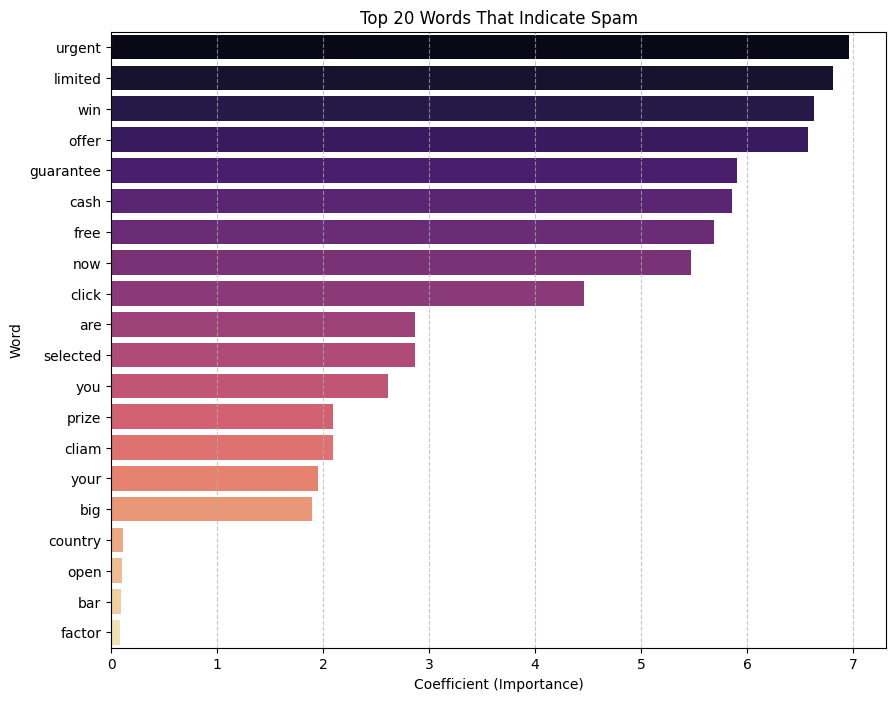

In [18]:
# Get feature names (words)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Get Logistic Regression model coefficients
coefficients = lr_model.coef_[0]

# Create a DataFrame for easier visualization
feature_importance = pd.DataFrame({'word': feature_names, 'importance': coefficients})

# Sort by importance and take the top 20 for Spam (highest coefficients)
top_spam = feature_importance.sort_values(by='importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='word', hue='word', legend=False, data=top_spam, palette='magma')
plt.title('Top 20 Words That Indicate Spam')
plt.xlabel('Coefficient (Importance)')
plt.ylabel('Word')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Custom Inference Function

Now we'll define a function that takes a raw string, processes it, and returns the prediction using our trained model.

In [19]:
def predict_spam(email_text):
    # 1. Transform the input text using the existing vectorizer
    vectorized_text = tfidf_vectorizer.transform([email_text])

    # 2. Get prediction and probability
    prediction = lr_model.predict(vectorized_text)[0]
    probability = lr_model.predict_proba(vectorized_text)[0]

    # 3. Format output
    result = "SPAM" if prediction == 1 else "HAM (Not Spam)"
    confidence = probability[prediction] * 100

    print(f"Content: {email_text[:100]}...")
    print(f"Prediction: {result}")
    print(f"Confidence: {confidence:.2f}%")

    return result

In [20]:
# Test the function with a custom string
my_email = "Congratulations! You have been selected to win a free $1000 gift card. Click here now to claim your prize!"

predict_spam(my_email)

Content: Congratulations! You have been selected to win a free $1000 gift card. Click here now to claim your ...
Prediction: SPAM
Confidence: 79.29%


'SPAM'

## Conversion to ONNX Format
ONNX (Open Neural Network Exchange) allows running the model in an optimized runtime independently of the original library.

In [21]:
# 1. Create a Pipeline containing both steps (Vectorization + Model). This is vital so the input to ONNX is the plain text directly.
full_pipeline = Pipeline([('vectorizer', tfidf_vectorizer), ('classifier', nb_model)])

# 2. Define the input type (a string)
initial_type = [('label_input', StringTensorType([None, 1]))]

# 3. Convert to ONNX
onnx_model = convert_sklearn(full_pipeline, initial_types=initial_type)

# 4. Save the file
with open("spam_model.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())